In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

import pprint
import warnings

In [2]:
# import STlouis csv file
train = pd.read_csv('/Users/lydia22/Desktop/Group6/AACUW_Team6/Datasets/Phoenix_arpa.csv')
#correct to your own path

In [3]:
df = train.copy()
df.head(5)

,Investment Focus,Program Type,Program,Amount,Amount Type,Date Allocated,As of Date
0,City Operations,City Operations,"Administrative Oversight, Compliance & Outreac...",1905888,Actual Spend Amount,6/8/2021,12/31/2024
1,City Operations,City Operations,"Administrative Oversight, Compliance & Outreac...",1917403,Budgeted Amount,6/8/2021,12/31/2024
2,Community Investment,Affordable Housing and Homelessness,Affordable Housing Program,1814023,Actual Spend Amount,6/7/2022,12/31/2024
3,Community Investment,Affordable Housing and Homelessness,Affordable Housing Program,16000000,Budgeted Amount,6/7/2022,12/31/2024
4,Community Investment,Neighborhood Sustainability,After-School Grant for Phoenix Schools,601463,Actual Spend Amount,6/8/2021,12/31/2024


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Investment Focus  146 non-null    object
 1   Program Type      146 non-null    object
 2   Program           146 non-null    object
 3       Amount        146 non-null    object
 4   Amount Type       146 non-null    object
 5   Date Allocated    146 non-null    object
 6   As of Date        146 non-null    object
dtypes: object(7)
memory usage: 8.1+ KB


In [5]:
df['Program Type'].value_counts()

Affordable Housing and Homelessness            40
Neighborhood Sustainability                    32
Workforce                                      30
Education                                      16
Phoenix Resilient Food System                  14
City Operations                                 8
Better Health & Community Outcomes              2
Premium Pay                                     1
Revenue Replacement                             1
Infrastructure, Technology, & Capital Needs     1
PPE/Heat Relief                                 1
Name: Program Type, dtype: int64

In [7]:
print(df.columns)

Index(['Investment Focus', 'Program Type', 'Program', '    Amount    ',
       'Amount Type', 'Date Allocated', 'As of Date'],
      dtype='object')


In [9]:
# time series analysis: date vs amount 
df['Date Allocated'] = pd.to_datetime(df['Date Allocated']) #change to the datetime 
df_time_series = df.groupby('Date Allocated')['    Amount    '].sum().reset_index()
#groupby function with the df, group by Date, sum up the amount and reset the index of the date
df_time_series

,Date Allocated,Amount
0,2021-06-08,1905888191740360146360146424499585000000192329...
1,2021-12-15,21073250
2,2022-04-12,1288775719352581
3,2022-06-07,1814023160000002940182940182187000500000021198...
4,2022-12-14,102212391416297271378628906780
5,2023-02-01,495774496771
6,2023-05-03,431089443145
7,2023-11-15,7128477128471438622242074410000001000000
8,2024-02-21,15306227000010680001521000
9,2024-08-01,$- 538000


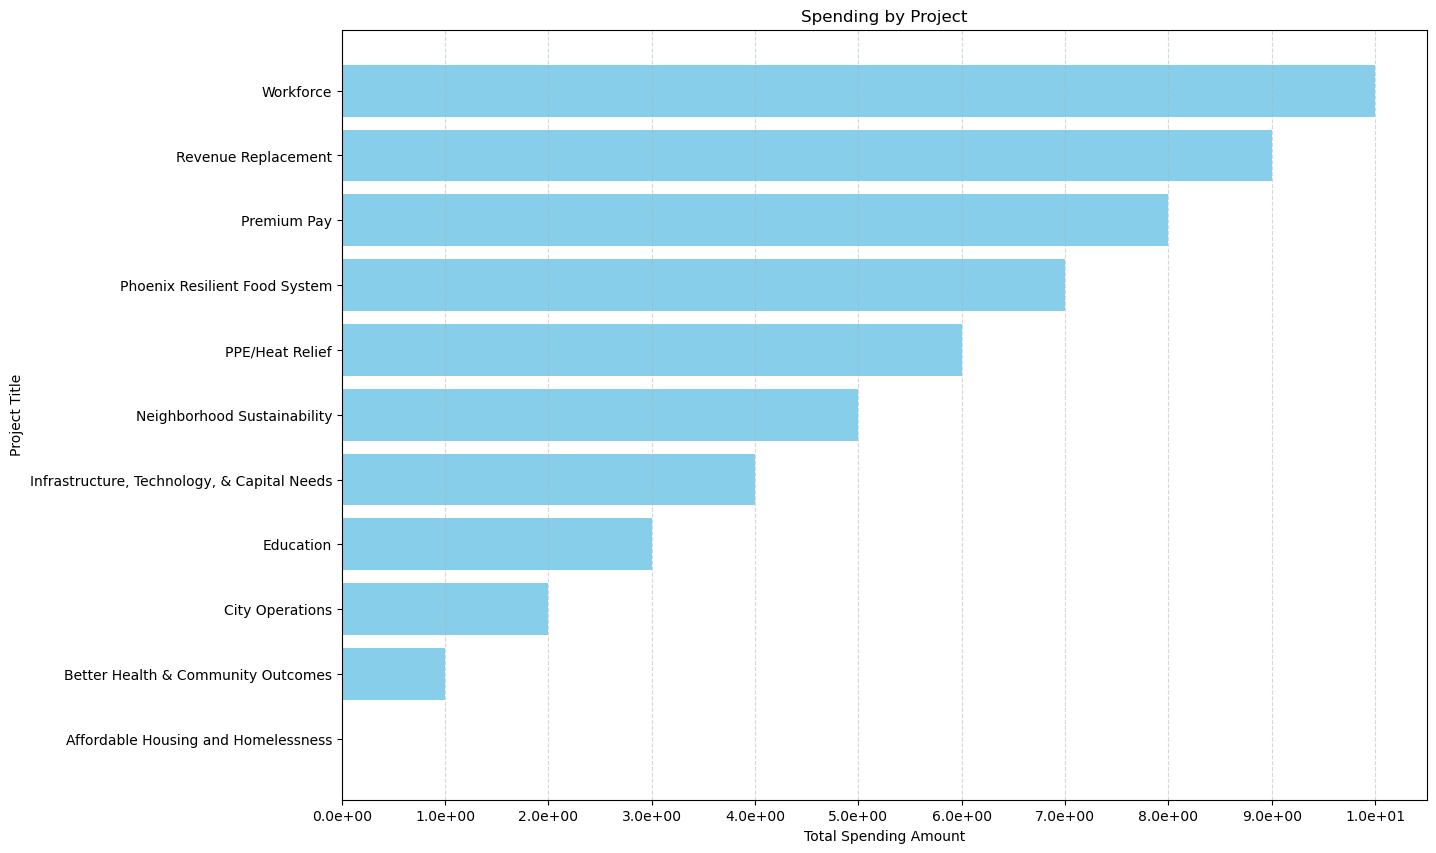

In [14]:
import matplotlib.ticker as ticker
# Spending by Project: projectile vs amount 
df_selected = df[['Program Type','    Amount    ']]
df_project = df_selected.groupby('Program Type')['    Amount    '].sum().reset_index()
#df_project = df_project.sort_values(by='AMOUNT', ascending=False) arrange with order

plt.figure(figsize=(14,10))

# bar plot
plt.barh(df_project['Program Type'], df_project['    Amount    '], color='skyblue')
plt.xlabel("Total Spending Amount")
plt.ylabel("Project Title")
plt.title("Spending by Project")
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1e}')) 
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()